<a href="https://colab.research.google.com/github/antonDinkov/AI_integrationsForDev/blob/main/Regular_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

- Set `OPENAI_API_KEY`
- Set `GEMINI_API_KEY`
- Set `ELEVENLABS_API_KEY`
- Upload the PDF file in the Colab session storage

In [2]:
!pip install -q chromadb openai pypdf google-genai elevenlabs

In [3]:
import base64
import io
import os

from IPython.display import Audio, Image, display
from chromadb import PersistentClient
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction
from elevenlabs import ElevenLabs
from google import genai
from google.genai import types
from pathlib import Path
from PIL import Image as PILImage
from pydantic import BaseModel
from pypdf import PdfReader
from typing import Literal

In [4]:
from google.colab import userdata
from openai import OpenAI

openai_api_key = userdata.get("OPEN_AI_API_KEY")
gemini_api_key = userdata.get("Gemini_API_Key")
elevenlabs_api_key = userdata.get("ELEVENLABS_API_KEY")

openai_client = OpenAI(api_key=openai_api_key)
gemini_client = genai.Client(api_key=gemini_api_key)
elevenlabs_client = ElevenLabs(api_key=elevenlabs_api_key)

In [46]:
OPENAI_TEXT_MODEL = "gpt-5.4-nano-2026-03-17"
OPENAI_EMBEDDING_MODEL = "text-embedding-3-small"

GEMINI_IMAGE_MODEL = "gemini-3.1-flash-lite-image"

ELEVENLABS_MODEL = "eleven_flash_v2_5"

ELEVENLABS_VOICE_ID = "zX2tU5GM7OSuYa2xQ0Bc"

## Extract content from the PDF file

In [7]:
path_to_pdf = Path(
    "/content/euclid's_book_on_division_of_figures-pdf.pdf"
)

pdf_reader = PdfReader(path_to_pdf)

In [8]:
print(f"There are {len(pdf_reader.pages)} pages in total.")

There are 111 pages in total.


In [9]:
text_fragments = []

for page_number, page in enumerate(pdf_reader.pages, start=1):
    page_text = page.extract_text() or ""

    text_fragments.append(
        f"\n\n===== PDF PAGE {page_number} =====\n\n"
        f"{page_text}"
    )

text = "\n".join(text_fragments)

In [10]:
print(f"There are {len(text)} characters in total.")

There are 206793 characters in total.


## Chunk the PDF content

In [12]:
text_chunks = []

start = 0
length = 1200
overlap = 250

while start < len(text):
    end = start + length
    current_chunk = text[start:end]

    if current_chunk.strip():
        text_chunks.append(current_chunk)

    start = end - overlap

In [13]:
print(f"There are {len(text_chunks)} chunks in total.")

There are 218 chunks in total.


In [14]:
print(text_chunks[0])



===== PDF PAGE 1 =====

The Project Gutenberg EBook of Euclid’s Book on Divisions of Figures, by
Raymond Clare Archibald
This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever. You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.org
Title: Euclid’s Book on Divisions of Figures
Author: Raymond Clare Archibald
Release Date: January 21, 2012 [EBook #38640]
Language: English
Character set encoding: ISO-8859-1
*** START OF THIS PROJECT GUTENBERG EBOOK EUCLID’S BOOK ON DIVISIONS ***


===== PDF PAGE 2 =====

Produced by Joshua Hutchinson, Ralph Carmichael and the
Online Distributed Proofreading Team at http://www.pgdp.net
(This file was produced from images from the Cornell
University Library: Historical Mathematics Monographs
collection.)
transcriber’s note
This book was produced from images provided by the Cornell
University Library: Historical Mathemati

## Setup the Vector Database

In [15]:
chroma_client = PersistentClient("/content/chroma")

In [16]:
collection_name = "euclid_divisions"

try:
    chroma_client.delete_collection(name=collection_name)
except Exception:
    pass

In [17]:
embedding_function = OpenAIEmbeddingFunction(
    api_key=openai_api_key,
    model_name=OPENAI_EMBEDDING_MODEL
)

chroma_collection = chroma_client.get_or_create_collection(
    name=collection_name,
    embedding_function=embedding_function
)

In [18]:
ids = [
    f"chunk_{index + 1}"
    for index in range(len(text_chunks))
]

documents = [
    chunk
    for chunk in text_chunks
]

metadatas = [
    {
        "source": path_to_pdf.name,
        "chunk_number": index + 1
    }
    for index in range(len(text_chunks))
]

In [19]:
batch_size = 100

for start_index in range(0, len(documents), batch_size):
    end_index = start_index + batch_size

    chroma_collection.add(
        ids=ids[start_index:end_index],
        documents=documents[start_index:end_index],
        metadatas=metadatas[start_index:end_index]
    )

print(
    f"There are {chroma_collection.count()} documents "
    "stored in the vector database."
)

There are 218 documents stored in the vector database.


In [20]:
semantic_search_results = chroma_collection.query(
    query_texts=[
        "What is Euclid's Book on Divisions of Figures about?"
    ],
    n_results=5,
    include=["distances", "documents", "metadatas"]
)

semantic_search_results

{'ids': [['chunk_8', 'chunk_32', 'chunk_1', 'chunk_33', 'chunk_61']],
 'embeddings': None,
 'documents': [['n Divisions of Figures 21\n20 Practical Applications of the problems on Divisions\nof Figures; theμετρικά of Heron of Alexandria 23\n21 Connection between Euclid’s BookOn Divisions,\nApollonius’s treatiseOn Cutting oﬀ a Spaceand a\nPappus-lemma to Euclid’s book ofPorisms 24\nIII\n22–57 Restoration of Euclid’sπερὶ διαιρέσεων βιβλίον 27\nIV\nAppendix 79\nIndex of Names 91\n\n\n===== PDF PAGE 11 =====\n\nI.\nProclus, and Euclid’s book On Divisions.\n1. Last in a list of Euclid’s works “full of admirable diligence and skilful\nconsideration,” Proclus mentions, without comment,περὶ διαιρέσεων βιβλίον 1.\nBut a little later2 in speaking of the conception or deﬁnition ofﬁgureand of the\ndivisibility of a ﬁgure into others diﬀering from it in kind, Proclus adds: “For\nthe circle is divisible into parts unlike in deﬁnition or notion, and so is each of\nthe rectilineal ﬁgures; this is in f

## Retrieve information

In [21]:
def retrieve_information(prompt: str) -> str:
    """
    Retrieve relevant information from the PDF and generate
    a grounded text answer.

    The PDF document is the only factual source used by this function.
    """

    if not isinstance(prompt, str):
        raise TypeError("The prompt must be a string.")

    if not prompt.strip():
        raise ValueError("The prompt cannot be empty.")

    semantic_search_results = chroma_collection.query(
        query_texts=[prompt],
        n_results=6,
        include=["documents", "metadatas", "distances"]
    )

    retrieved_documents = semantic_search_results["documents"][0]
    retrieved_metadatas = semantic_search_results["metadatas"][0]

    context_fragments = []

    for document, metadata in zip(
        retrieved_documents,
        retrieved_metadatas
    ):
        context_fragments.append(
            f"Source: {metadata['source']}, "
            f"chunk: {metadata['chunk_number']}\n"
            f"{document}"
        )

    context = "\n\n====================\n\n".join(
        context_fragments
    )

    conversation = [
        {
            "role": "developer",
            "content": """
You are an assistant that answers questions about
Euclid's Book on Divisions of Figures.

Use ONLY the document excerpts provided in the user's message.

Rules:

1. Do not use external knowledge.
2. Do not invent facts, names, dates, propositions or explanations.
3. If the answer is not available in the provided excerpts, clearly
   state that the information could not be found in the retrieved
   parts of the PDF.
4. Answer in the same language as the question.
5. Be accurate, clear and sufficiently detailed.
6. When the excerpts contain a PDF page marker, mention the relevant
   page number where appropriate.
7. Do not claim that something appears in the book unless it is
   supported by the supplied excerpts.
"""
        },
        {
            "role": "user",
            "content": f"""
Question:

{prompt}

Relevant excerpts retrieved from the PDF:

{context}
"""
        }
    ]

    response = openai_client.responses.create(
        model=OPENAI_TEXT_MODEL,
        input=conversation
    )

    return response.output_text

In [22]:
answer = retrieve_information(
    "What is the main purpose of Archibald's book?"
)

print(answer)

From the **“Introductory”** section (see the paragraph that begins “necessary commentary”), the main purpose of Archibald’s book is:

- **To provide a restoration of Euclid’s work**—specifically, **“a restoration of Euclid’s work based on the Woepcke text and on a thirteenth century geometry of Leonardo Pisano”** (PDF page not explicitly marked in this excerpt, but it occurs in the Introductory material).
- Alongside this main goal, the book also aims:
  1. **To take due account of various manuscript-related questions** (including MSS. of “Muhammed Bagdedinus” and the Dee-Commandinus book on divisions of figures).
  2. **To indicate writers prior to 1500** who dealt with propositions from Euclid’s work.
  3. **To select from an extensive bibliography** of the subject during the past 400 years.


## Detect the question and the preferred response format

In [24]:
class IntermediateResponse(BaseModel):
    prompt: str
    format: Literal["text", "image", "audio"]

In [25]:
def extract_request_data(question: str) -> IntermediateResponse:
    """
    Extract the document question and the preferred response format
    with OpenAI Structured Outputs.
    """

    if not isinstance(question, str):
        raise TypeError("The question must be a string.")

    if not question.strip():
        raise ValueError("The question cannot be empty.")

    intermediate_response = openai_client.responses.parse(
        model=OPENAI_TEXT_MODEL,
        input=[
            {
                "role": "developer",
                "content": """
Extract the user's core question about the PDF document and
the user's preferred output format.

Return exactly two structured fields:

- prompt
- format

The format must be exactly one of:

- text
- image
- audio

Instructions:

1. Remove only the part of the request that specifies how the answer
   should be presented.
2. Preserve the complete factual question in the prompt.
3. If the user asks to show, draw, visualize, illustrate, generate
   or create a picture, select image.
4. If the user asks to hear, listen to, read aloud, narrate, speak
   or return speech, select audio.
5. If the user asks for a written answer, explanation, summary,
   list or does not specify a format, select text.
6. Do not answer the question yourself.
7. The prompt must be a standalone question that can be sent to
   the document retrieval function.
"""
            },
            {
                "role": "user",
                "content": question
            }
        ],
        text_format=IntermediateResponse
    )

    if intermediate_response.output_parsed is None:
        raise RuntimeError(
            "OpenAI could not extract the requested structured data."
        )

    return intermediate_response.output_parsed

In [26]:
test_request = extract_request_data(
    "Show me an image explaining the main types of figures "
    "divided in Euclid's treatise."
)

print(test_request)

prompt="Show me an image explaining the main types of figures divided in Euclid's treatise." format='image'


## Generate an image with Gemini

In [27]:
def generate_image(
    original_question: str,
    document_answer: str
) -> bytes:
    """
    Generate an image with Gemini.

    The generated image prompt is built only from the answer
    retrieved from the PDF.
    """

    image_prompt = f"""
Create a clear educational image based on the verified information
below from Euclid's Book on Divisions of Figures.

Original user request:

{original_question}

Verified answer retrieved from the PDF:

{document_answer}

Image requirements:

- Use only the verified information supplied above.
- Do not introduce additional historical claims.
- Do not invent proposition numbers, dates, quotations or names.
- Create a visually interesting educational geometry illustration.
- Show geometric figures and their divisions where appropriate.
- Use a clean academic style.
- The illustration should be understandable to a student.
- Avoid long paragraphs of text inside the image.
- Do not present invented content as a quotation from Euclid.
"""

    response = gemini_client.models.generate_content(
        model=GEMINI_IMAGE_MODEL,
        contents=image_prompt,
        config=types.GenerateContentConfig(
            response_modalities=["IMAGE"]
        )
    )

    if not response.candidates:
        raise RuntimeError(
            "Gemini did not return any response candidates."
        )

    candidate = response.candidates[0]

    if candidate.content is None:
        raise RuntimeError(
            "Gemini returned an empty response."
        )

    for part in candidate.content.parts:
        if part.inline_data is not None:
            return part.inline_data.data

    raise RuntimeError(
        "Gemini did not return image data."
    )

## Generate audio with ElevenLabs

In [28]:
def generate_audio(document_answer: str) -> Path:
    """
    Convert the PDF-grounded answer to speech with ElevenLabs.
    """

    if ELEVENLABS_VOICE_ID == "YOUR_ELEVENLABS_VOICE_ID":
        raise ValueError(
            "Replace YOUR_ELEVENLABS_VOICE_ID with a valid "
            "voice ID from your ElevenLabs account."
        )

    audio_response = elevenlabs_client.text_to_speech.convert(
        voice_id=ELEVENLABS_VOICE_ID,
        model_id=ELEVENLABS_MODEL,
        output_format="mp3_44100_128",
        text=document_answer
    )

    path_to_audio = Path("/content/last_answer.mp3")

    with open(path_to_audio, "wb") as audio_file:
        for audio_chunk in audio_response:
            if audio_chunk:
                audio_file.write(audio_chunk)

    return path_to_audio

## Main AI function

In [29]:
def ask_ai(question: str, verbose: bool = True):
    """
    Understand the user's request, retrieve information from the PDF
    and return the answer as text, image or audio.
    """

    request_data = extract_request_data(question)

    if verbose:
        print("Intermediate structured response:")
        print(request_data)
        print()

    answer = retrieve_information(request_data.prompt)

    if verbose:
        print("Answer retrieved from the PDF:")
        print(answer)
        print()

    if request_data.format == "text":
        print(answer)
        return answer

    elif request_data.format == "image":
        image_bytes = generate_image(
            original_question=question,
            document_answer=answer
        )

        path_to_image = Path("/content/last_answer.png")
        path_to_image.write_bytes(image_bytes)

        display(
            Image(
                data=image_bytes,
                format="png"
            )
        )

        return path_to_image

    elif request_data.format == "audio":
        path_to_audio = generate_audio(answer)

        display(
            Audio(
                filename=str(path_to_audio),
                autoplay=False
            )
        )

        return path_to_audio

    else:
        raise RuntimeError(
            f"Unsupported response format: {request_data.format}"
        )

## Test Case 1 — Text response

In [30]:
ask_ai(
    "What is the main purpose of Archibald's restoration of "
    "Euclid's Book on Divisions of Figures? Give me a text answer."
)

Intermediate structured response:
prompt="What is the main purpose of Archibald's restoration of Euclid's Book on Divisions of Figures?" format='text'

Answer retrieved from the PDF:
Archibald’s main purpose is **“to give, with necessary commentary, a restoration of Euclid’s work”** on divisions of figures—specifically **based on Woepcke’s text** and **on the *Practica Geometriae* of Leonardo Pisano** (see the “In this little volume I have attempted” list, point (1)).

Archibald’s main purpose is **“to give, with necessary commentary, a restoration of Euclid’s work”** on divisions of figures—specifically **based on Woepcke’s text** and **on the *Practica Geometriae* of Leonardo Pisano** (see the “In this little volume I have attempted” list, point (1)).


'Archibald’s main purpose is **“to give, with necessary commentary, a restoration of Euclid’s work”** on divisions of figures—specifically **based on Woepcke’s text** and **on the *Practica Geometriae* of Leonardo Pisano** (see the “In this little volume I have attempted” list, point (1)).'

## Test Case 2 — Text response

In [31]:
ask_ai(
    "What works by Euclid are mentioned in the introductory "
    "part of the document? Answer as text."
)

Intermediate structured response:
prompt='What works by Euclid are mentioned in the introductory part of the document?' format='text'

Answer retrieved from the PDF:
In the introductory part of the document, the following works by Euclid are mentioned:

- **“περὶ διαιρέσεων βιβλίον” (Divisions)** — referenced as **Euclid’s book “On Divisions.”** (See the section heading and discussion beginning **Book I, paragraph 1** on **PDF page 11**: “Proclus mentions… περύ διαιρέσεων βιβλίον…”, and it is also described earlier in the contents as **“Euclid’s BookOn Divisions of Figures.”**)
- **No other Euclid works** are named in the excerpts provided; the rest of the material in the introduction cites other authors/translations and commentary.

In the introductory part of the document, the following works by Euclid are mentioned:

- **“περὶ διαιρέσεων βιβλίον” (Divisions)** — referenced as **Euclid’s book “On Divisions.”** (See the section heading and discussion beginning **Book I, paragraph 1** 

'In the introductory part of the document, the following works by Euclid are mentioned:\n\n- **“περὶ διαιρέσεων βιβλίον” (Divisions)** — referenced as **Euclid’s book “On Divisions.”** (See the section heading and discussion beginning **Book I, paragraph 1** on **PDF page 11**: “Proclus mentions… περύ διαιρέσεων βιβλίον…”, and it is also described earlier in the contents as **“Euclid’s BookOn Divisions of Figures.”**)\n- **No other Euclid works** are named in the excerpts provided; the rest of the material in the introduction cites other authors/translations and commentary.'

## Test Case 3 — Text response

In [32]:
ask_ai(
    "How many propositions are included in the restored version "
    "of Euclid's treatise? Give me a written answer."
)

Intermediate structured response:
prompt="How many propositions are included in the restored version of Euclid's treatise?" format='text'

Answer retrieved from the PDF:
The restored version of Euclid’s treatise includes **thirty-six propositions**. This is stated in the PDF excerpt (in the introduction): “the third part contains the restoration proper, with its **thirty-six propositions**.” (see the excerpt provided in the section before **PDF PAGE 9**).

The restored version of Euclid’s treatise includes **thirty-six propositions**. This is stated in the PDF excerpt (in the introduction): “the third part contains the restoration proper, with its **thirty-six propositions**.” (see the excerpt provided in the section before **PDF PAGE 9**).


'The restored version of Euclid’s treatise includes **thirty-six propositions**. This is stated in the PDF excerpt (in the introduction): “the third part contains the restoration proper, with its **thirty-six propositions**.” (see the excerpt provided in the section before **PDF PAGE 9**).'

## Test Case 4 — Text response

In [33]:
ask_ai(
    "Summarize the evidence connecting the Woepcke manuscript "
    "with Euclid's original work. Return text."
)

Intermediate structured response:
prompt="Summarize the evidence connecting the Woepcke manuscript with Euclid's original work." format='text'

Answer retrieved from the PDF:
The retrieved text provides several pieces of “evidence” (i.e., stated observations and scholarly conclusions) intended to connect the Woepcke manuscript material to Euclid’s original work:

1. **Woepcke’s treatise is described as complete (not a fragment).**  
   The excerpt says that it is “expressly stated” that the treatise published by Woepcke “is no fragment but the complete work,” with the phrase “ﬁn du traité,” and it further states that it is “a well ordered and compact whole” (chunk 35; note references “Woepcke, p. 244”).

2. **Matching propositions between the “Dee” work and Woepcke are asserted.**  
   The excerpt compares numbered propositions across two sources: it states that **Dee 12 = Woepcke 32**, and that **Woepcke 3 is only a special case of Dee 2**, while **Woepcke 6, 7, 8, 9** are “easily sol

'The retrieved text provides several pieces of “evidence” (i.e., stated observations and scholarly conclusions) intended to connect the Woepcke manuscript material to Euclid’s original work:\n\n1. **Woepcke’s treatise is described as complete (not a fragment).**  \n   The excerpt says that it is “expressly stated” that the treatise published by Woepcke “is no fragment but the complete work,” with the phrase “ﬁn du traité,” and it further states that it is “a well ordered and compact whole” (chunk 35; note references “Woepcke, p. 244”).\n\n2. **Matching propositions between the “Dee” work and Woepcke are asserted.**  \n   The excerpt compares numbered propositions across two sources: it states that **Dee 12 = Woepcke 32**, and that **Woepcke 3 is only a special case of Dee 2**, while **Woepcke 6, 7, 8, 9** are “easily solved by Dee 8.” It then adds: “it can hardly be chance that the proofs of exactly these propositions in Dee should be without fault” (chunk 35).\n\n3. **A conclusion is 

## Test Case 5 — Text response

In [34]:
ask_ai(
    "What role does Leonardo Pisano's Practica Geometriae play "
    "in Archibald's restoration? Explain in text."
)

Intermediate structured response:
prompt="What role does Leonardo Pisano's Practica Geometriae play in Archibald's restoration? Explain." format='text'

Answer retrieved from the PDF:
Leonardo Pisano’s *Practica Geometriae* plays a **key supportive role** in Archibald’s restoration of Euclid’s *On Divisions of Figures*, because Archibald uses it as **one of the two main bases** for the restoration (the other being **Woepcke’s text**) (see the title page: “WITH A RESTORATION BASED ON WOEPCKE’S TEXT AND ON THE PRACTICA GEOMETRIAE OF LEONARDO PISANO,” PDF p. 3).

In particular, Archibald explains that:

- **A dedicated section for divisions of figures:** Favaro (as Archibald reports) drew attention to *Section IIII* of Leonardo’s *Practica Geometriae*, which is “wholly devoted to the enunciation and proof and numerical exemplification of propositions concerning the divisions of figures.” Favaro reproduces and numbers these propositions (PDF p. 19, lines beginning “10. … This section…”).



'Leonardo Pisano’s *Practica Geometriae* plays a **key supportive role** in Archibald’s restoration of Euclid’s *On Divisions of Figures*, because Archibald uses it as **one of the two main bases** for the restoration (the other being **Woepcke’s text**) (see the title page: “WITH A RESTORATION BASED ON WOEPCKE’S TEXT AND ON THE PRACTICA GEOMETRIAE OF LEONARDO PISANO,” PDF p. 3).\n\nIn particular, Archibald explains that:\n\n- **A dedicated section for divisions of figures:** Favaro (as Archibald reports) drew attention to *Section IIII* of Leonardo’s *Practica Geometriae*, which is “wholly devoted to the enunciation and proof and numerical exemplification of propositions concerning the divisions of figures.” Favaro reproduces and numbers these propositions (PDF p. 19, lines beginning “10. … This section…”).\n\n- **Substantial overlap with Woepcke’s propositions:** Archibald notes that there is a close correspondence between Leonardo and Woepcke:  \n  - In Archibald’s account, **at lea

In [35]:
## Test Case 6 — Text response

In [36]:
ask_ai(
    "What types of figures are divided in Euclid's treatise? "
    "Give me a concise text answer."
)

Intermediate structured response:
prompt="What types of figures are divided in Euclid's treatise?" format='text'

Answer retrieved from the PDF:
In Euclid’s treatise **On Divisions of Figures**, the **figures divided** include the following types:

- **Triangle** (1–14)  
- **Parallelogram** (15–22)  
- **Trapezium** (23–35)  
- **Quadrilateral** (36–41)  
- **Pentagon** (42–43)  
- **Hexagon** (44)  
- **Circle and semicircle** (45–56)  
- **A figure bounded by an arc of a circle and two lines** (57)

(Source: “Synopsis of Euclid’s Treatise—II. The ﬁgures divided” in the excerpt on **PDF page 24**, labeled “14 EUCLID’S BOOK ON DIVISION OF FIGURES I [17”).)

In Euclid’s treatise **On Divisions of Figures**, the **figures divided** include the following types:

- **Triangle** (1–14)  
- **Parallelogram** (15–22)  
- **Trapezium** (23–35)  
- **Quadrilateral** (36–41)  
- **Pentagon** (42–43)  
- **Hexagon** (44)  
- **Circle and semicircle** (45–56)  
- **A figure bounded by an arc of a

'In Euclid’s treatise **On Divisions of Figures**, the **figures divided** include the following types:\n\n- **Triangle** (1–14)  \n- **Parallelogram** (15–22)  \n- **Trapezium** (23–35)  \n- **Quadrilateral** (36–41)  \n- **Pentagon** (42–43)  \n- **Hexagon** (44)  \n- **Circle and semicircle** (45–56)  \n- **A figure bounded by an arc of a circle and two lines** (57)\n\n(Source: “Synopsis of Euclid’s Treatise—II. The ﬁgures divided” in the excerpt on **PDF page 24**, labeled “14 EUCLID’S BOOK ON DIVISION OF FIGURES I [17”).)'

## Test Case 7 — Image response

Intermediate structured response:
prompt="Create an educational image showing the types of geometric figures divided in Euclid's treatise." format='image'

Answer retrieved from the PDF:
I can’t create a complete “types of geometric figures divided” image from the provided PDF excerpts alone, because the excerpts include only part of the list.

However, the following **types of figures divided** are explicitly stated in the retrieved text (see **PDF page 24**, section II):

- **Triangle** (propositions 1–14)  
- **Parallelogram** (propositions 15–22)  
- **Trapezium** (propositions 23–35)  
- **Quadrilateral** (propositions 36–41)  
- **Pentagon** (propositions 42–43)  
- **Hexagon** (proposition 44)  
- **Circle and semicircle** (propositions 45–56)  
- **A figure bounded by an arc of a circle and two lines** (proposition 57)

If you want, I can turn just this excerpt-supported list into an educational image prompt/layout (e.g., a poster-style diagram with labeled shapes). But I would

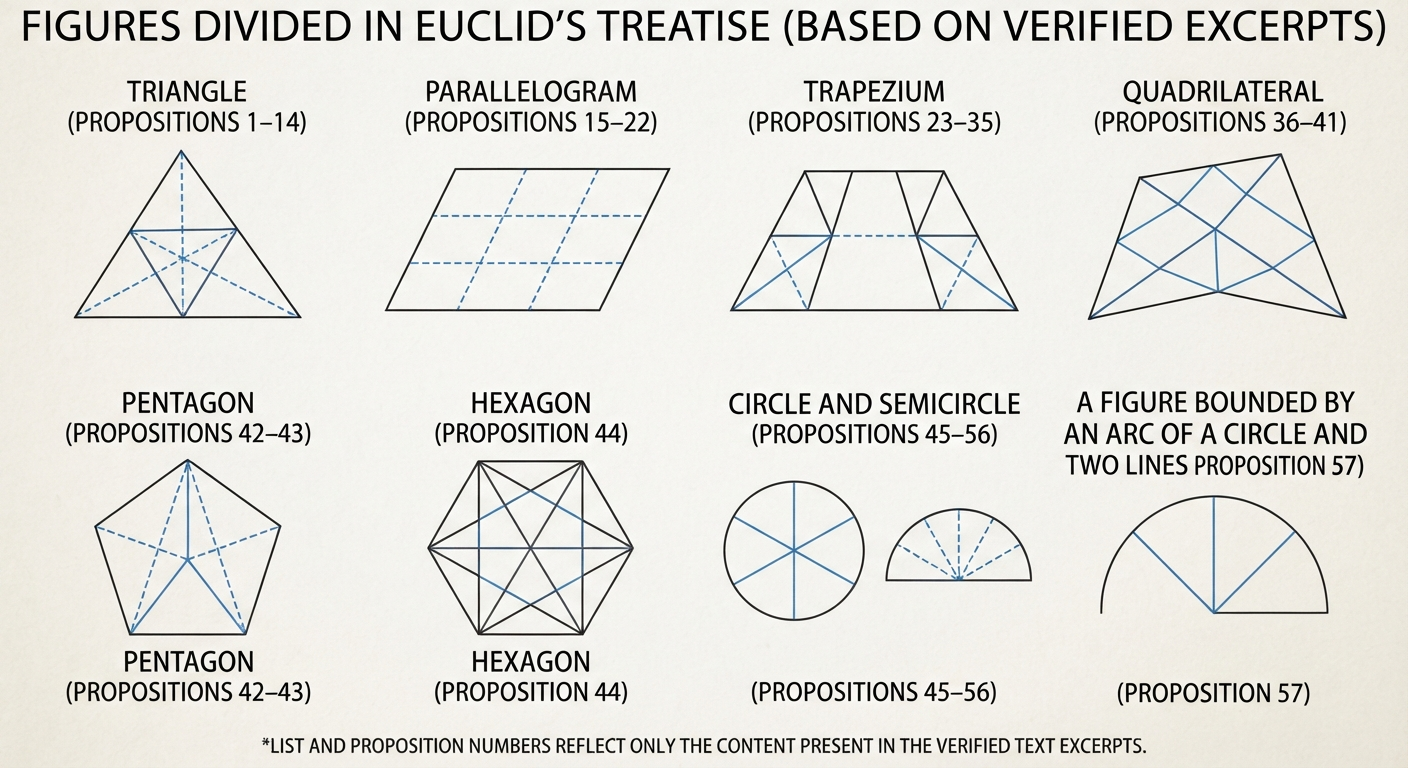

PosixPath('/content/last_answer.png')

In [37]:
ask_ai(
    "Create an educational image showing the types of geometric "
    "figures divided in Euclid's treatise."
)

## Test Case 8 — Audio response

In [47]:
ask_ai(
    "Read aloud a concise explanation of what Euclid's "
    "Book on Divisions of Figures is about."
)

Intermediate structured response:
prompt="Read aloud a concise explanation of what Euclid's Book on Divisions of Figures is about." format='audio'

Answer retrieved from the PDF:
Euclid’s *Book on Divisions of Figures* is concerned with **how to divide given plane figures into parts**—either **into other figures of the same kind** (e.g., triangles into triangles) or **into unlike figures** (e.g., a triangle divided by a straight line parallel to its base). This “business” of the work is described as dividing given figures “in one case into like figures, and in another into unlike.” (See the discussion on **PDF page 11**.)

The book includes results such as **dividing a given triangle into equal parts by a line parallel to its base**, stated as **Proposition 1 (PDF page 37)**.



PosixPath('/content/last_answer.mp3')

## Test Case 9 — Additional image response

Intermediate structured response:
prompt='Visualize in an image the idea of dividing a triangle into equal parts as discussed in the document.' format='image'

Answer retrieved from the PDF:
Below is a simple visualization (ASCII diagram) of the idea stated in the excerpt: a triangle can be divided into **equal-area parts** by drawing a suitable straight line.

### Divide a triangle into equal parts (equal-area regions)

In the document, it is shown (e.g., for a “one-third” case and then by similar reasoning) that parts of a triangle can be cut off by a **straight line** so that the **areas are in a specified proportion**. In particular, when the target is **equal parts** (e.g., “one half” / “two equal parts”), the method is to draw a straight line that produces equal-area triangular regions.

**Example layout (two equal parts):**

```
        A
       / \
      /   \
     /  E  \
    /       \
   B---------C

Line DZ (shown conceptually) drawn from a point to split the triangle into
t

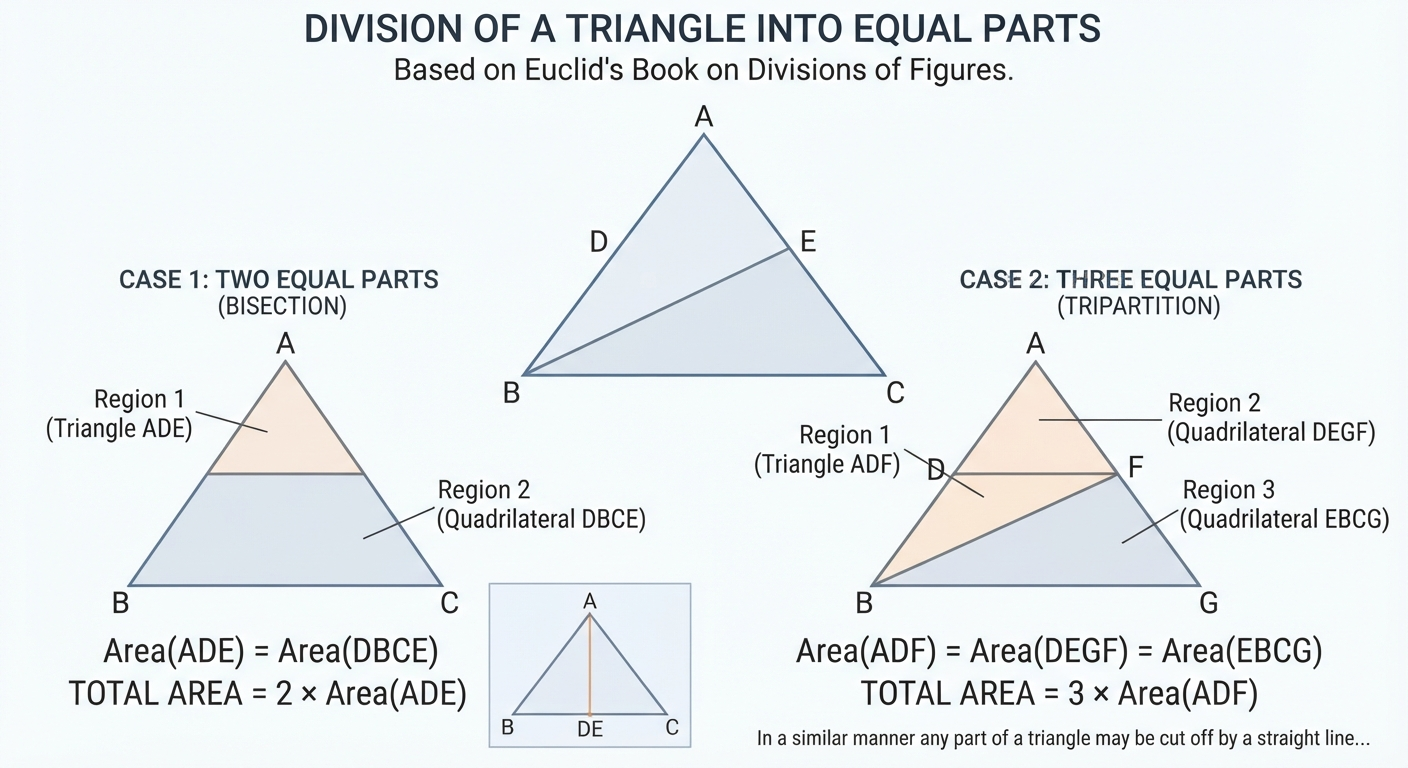

PosixPath('/content/last_answer.png')

In [39]:
ask_ai(
    "Visualize in an image the idea of dividing a triangle "
    "into equal parts as discussed in the document."
)

## Test Case 10 — Additional audio response

In [48]:
ask_ai(
    "Give me an audio summary of the relationship between "
    "Euclid's work and Leonardo Pisano's geometry."
)

Intermediate structured response:
prompt="Give me an audio summary of the relationship between Euclid's work and Leonardo Pisano's geometry." format='audio'

Answer retrieved from the PDF:
Here’s an audio-style summary of what the excerpts say about the relationship between Euclid’s work and Leonardo Pisano’s geometry.

---

In the excerpted discussion (pp. 19–21), the relationship is presented as a **close historical and textual connection** between Euclid’s *Divisions* and Leonardo Pisano’s **Practica Geometriae** (Fibonacci).

First, the text notes that Leonardo Pisano had a **wide range of knowledge**, including connections to **Euclid’s *Elements***. It says that his *Practica Geometriae* includes **many references to Euclid’s Elements**, and even **many uncredited extracts** from that work (see the section on pp. 20 [“Leonardo had a wide range of knowledge…”] and immediately following).

Second, it explains that Leonardo’s *Practica Geometriae* contains a section **wholly devoted

PosixPath('/content/last_answer.mp3')

## Verify generated files

In [49]:
generated_files = [
    Path("/content/last_answer.png"),
    Path("/content/last_answer.mp3")
]

for generated_file in generated_files:
    if generated_file.exists():
        print(
            f"{generated_file.name}: "
            f"{generated_file.stat().st_size} bytes"
        )
    else:
        print(f"{generated_file.name}: not generated yet")

last_answer.png: 603976 bytes
last_answer.mp3: 3813503 bytes
